# APWP method and temporal-resolution comparison

This notebook generates the Supporting Information figures that compare four approaches to constructing the Keweenawan apparent polar wander path (APWP) and evaluates APW rates at 1 Myr and 5 Myr spacing. Reusable spherical calculations, ensemble resampling, and Bayesian Euler-pole functions are documented in `vgptools/utils_method_comparison.py`.

## Time assigned to a moving-window pole

Two ages occur in the running-mean output and should not be conflated. The **moving-window center age** (`age`) is the requested evaluation grid: a pole at 1095 Ma uses VGPs within the 15 Myr window centered on 1095 Ma. The **rounded effective age** (`effective_age`) is the rounded arithmetic mean of the ages of the VGPs actually resampled into that window. Because the available observations and their age uncertainties are not distributed symmetrically, the effective age can differ from the window center and varies among bootstrap realizations.

Gallo et al. (2023) grouped all ensemble poles by rounded effective age. For each age, their rate workflow sampled one pole from that pooled group independently of the pole selected at the neighboring age, then divided the great-circle distance by the difference in rounded effective age. Thus the synthetic rate paths need not preserve the identity of an original bootstrap run. Figure 5 of the present study adopted this convention. To keep the revision comparisons methodologically consistent with Figure 5 and the published method, Figures S7 and S8 use the same pooled effective-age resampling below. A trajectory-coherent alternative remains available as `calculate_coherent_path_rates` for future sensitivity analysis.

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pmagpy import ipmag

cwd = Path.cwd().resolve()
ROOT = cwd.parent if cwd.name == 'code' else cwd
CODE_DIR = ROOT / 'code'
DATA_DIR = ROOT / 'data'
OUTPUT_DIR = CODE_DIR / 'apwp_output'
LOCAL_FIGURE_DIR = ROOT / 'figure'
MANUSCRIPT_FIGURE_DIR = ROOT.parent / 'APWP_StratModels_manuscript' / 'figures'
DOWNLOAD_DIR = Path.home() / 'Downloads'
sys.path.insert(0, str(CODE_DIR))

from vgptools.utils_method_comparison import (
    calculate_coherent_path_rates,
    cartesian_mean_path,
    gallo_effective_age_resample,
    load_two_euler_npz_paths,
    summarize_quantiles,
)
from vgptools.utils_APWPs import ensemble_RMs_parallel, ultimate_ensemble_RMs_parallel

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
LOCAL_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MANUSCRIPT_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.size': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

## Analysis settings

Both site-level ensembles use 3,000 bootstrap iterations and a triangular 15 Myr moving window evaluated at 1 Myr increments. The Gallo-style rate resampling creates 3,000 synthetic paths. Fixed random seeds make the plotted summaries reproducible. The Bayesian PEP chains are thinned by 100, retaining 8,000 posterior paths across four chains.

In [2]:
N_SIMS = 5000
WINDOW_LENGTH = 15.0
MIN_AGE = 1075.0
MAX_AGE = 1115.0
PEP_THIN = 100
COMMON_EFFECTIVE_AGES = np.arange(1075.0, 1111.0, 1.0)
FIVE_MYR_EFFECTIVE_AGES = np.arange(1075.0, 1111.0, 5.0)

## Site-level APWP ensembles

The updated ensemble samples posterior stratigraphic age models and inclination-shallowing factors during every realization. The comparison ensemble follows the Gallo et al. (2023) treatment without posterior stratigraphic age models. Cached tables are used when present; otherwise this cell reconstructs them from the repository's source data.

In [3]:
section_names = [
    'Osler Volcanic Group', 'Mamainse Point Volcanics',
    'North Shore Volcanic Group NE', 'North Shore Volcanic Group SW',
    'Portage Lake Volcanics', 'Michipicoten Island Formation', 'Oronto Group',
]
age_model_files = [
    'Osler_Volcanic_Group_posterior_ages.csv',
    'Mamainse_Point_Volcanic_Group_posterior_ages.csv',
    'NSVG_NE_posterior_ages.csv', 'NSVG_SW_posterior_ages.csv',
    'PLV_posterior_ages.csv', 'Michipicoten_posterior_ages.csv',
    'Oronto_Group_posterior_ages.csv',
]
age_models = pd.DataFrame(
    {'posterior_age_model': [pd.read_csv(DATA_DIR / 'age_models_output' / f) for f in age_model_files]},
    index=section_names,
)

sedimentary_sections = ['Freda Formation', 'Nonesuch Formation', 'Cut Face Creek Sandstone']
factor_files = [
    DATA_DIR / 'pmag_compiled' / 'Slotznick2023' / 'flattening_factors.csv',
    DATA_DIR / 'pmag_compiled' / 'Slotznick2023' / 'flattening_factors.csv',
    DATA_DIR / 'pmag_compiled' / 'Pierce2022' / 'flattening_factors.csv',
]
sedimentary_factors = pd.DataFrame(
    {'f_factors': [pd.read_csv(f, header=None) for f in factor_files]},
    index=sedimentary_sections,
)
site_data = pd.read_csv(DATA_DIR / 'pmag_compiled' / 'Keweenawan_track_sites_w_MAD_conversion.csv')

updated_cache = OUTPUT_DIR / f'revision_updated_age_model_rm_{N_SIMS}_window{int(WINDOW_LENGTH)}.csv.gz'
if updated_cache.exists():
    updated_rm = pd.read_csv(updated_cache)
else:
    np.random.seed(2024)
    updated_rm, _ = ultimate_ensemble_RMs_parallel(
        site_data, age_models, sedimentary_factors, n_sims=N_SIMS,
        min_age=MIN_AGE, max_age=MAX_AGE, window_length=WINDOW_LENGTH,
        time_step=1, n_jobs=max(1, (os.cpu_count() or 2) - 2),
    )
    updated_rm.to_csv(updated_cache, index=False)

gallo_cache = OUTPUT_DIR / f'revision_gallo_no_age_model_rm_{N_SIMS}_window{int(WINDOW_LENGTH)}.csv.gz'
if gallo_cache.exists():
    gallo_rm = pd.read_csv(gallo_cache)
else:
    np.random.seed(2025)
    gallo_sites = site_data.copy()
    gallo_sites['dir_f'] = np.where(gallo_sites['geologic_classes'].str.contains('Igneous'), 1.0, 0.6)
    gallo_sites['dir_f_sigma'] = np.nan
    gallo_sites.loc[gallo_sites['geologic_classes'] == 'Sedimentary', 'dir_f_sigma'] = 0.1
    gallo_rm, _ = ensemble_RMs_parallel(
        gallo_sites, n_sims=N_SIMS, min_age=MIN_AGE, max_age=MAX_AGE,
        window_length=WINDOW_LENGTH, time_step=1,
        n_jobs=max(1, (os.cpu_count() or 2) - 2),
    )
    gallo_rm.to_csv(gallo_cache, index=False)

updated_rm.shape, gallo_rm.shape

[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  48 tasks      | elapsed:    6.3s
[Parallel(n_jobs=12)]: Done 138 tasks      | elapsed:   11.5s
[Parallel(n_jobs=12)]: Done 264 tasks      | elapsed:   18.9s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:   29.5s
[Parallel(n_jobs=12)]: Done 624 tasks      | elapsed:   42.0s
[Parallel(n_jobs=12)]: Done 858 tasks      | elapsed:   56.1s
[Parallel(n_jobs=12)]: Done 1128 tasks      | elapsed:  1.2min
[Parallel(n_jobs=12)]: Done 1434 tasks      | elapsed:  1.5min
[Parallel(n_jobs=12)]: Done 1776 tasks      | elapsed:  1.8min
[Parallel(n_jobs=12)]: Done 2154 tasks      | elapsed:  2.2min
[Parallel(n_jobs=12)]: Done 2568 tasks      | elapsed:  2.6min
[Parallel(n_jobs=12)]: Done 3018 tasks      | elapsed:  3.0min
[Parallel(n_jobs=12)]: Done 3504 tasks      | elapsed:  3.5min
[Parallel(n_jobs=12)]: Done 4026 tasks      | elapsed:  4.0min
[Parallel(n_jobs=12)]: Done 4584 tasks      | e

((205000, 22), (205000, 22))

## Traditional running mean and Bayesian PEP paths

The traditional path is a 15 Myr Fisher running mean of published study-level poles. The Bayesian comparison evaluates the archived two-Euler, exponential-prior posterior samples directly from their transformed NPZ variables. Copies of all four original NPZ chains are stored under `data/bayesian_pep`, so this repository no longer depends on the separate Bayesian inversion checkout or its legacy PyMC environment.

In [4]:
traditional_cache = OUTPUT_DIR / f'revision_traditional_running_mean_window{int(WINDOW_LENGTH)}.csv'
if traditional_cache.exists():
    traditional_rm = pd.read_csv(traditional_cache)
else:
    poles = pd.read_csv(DATA_DIR / 'pmag_compiled' / 'Keweenawan_pole_means.csv').rename(
        columns={'PoleName': 'Study', 'PLon': 'plon', 'PLat': 'plat', 'AgeNominal': 'age'}
    )
    rows = []
    for age in np.arange(MIN_AGE, MAX_AGE + 1.0, 1.0):
        window = poles[(poles.age >= age - WINDOW_LENGTH / 2) & (poles.age <= age + WINDOW_LENGTH / 2)]
        if len(window) < 3:
            continue
        mean = ipmag.fisher_mean(window.plon.tolist(), window.plat.tolist())
        rows.append({'age': age, 'plon': mean['dec'] % 360, 'plat': mean['inc']})
    traditional_rm = pd.DataFrame(rows).assign(run=0)
    traditional_rm = calculate_coherent_path_rates(traditional_rm)
    traditional_rm.to_csv(traditional_cache, index=False)

pep_cache = OUTPUT_DIR / f'revision_pep_2e_exp_paths_thin{PEP_THIN}.csv.gz'
if pep_cache.exists():
    pep_paths = pd.read_csv(pep_cache)
else:
    chain_paths = sorted((DATA_DIR / 'bayesian_pep' / 'kewee_2_euler_exp_trace').glob('*/samples.npz'))
    pep_paths = load_two_euler_npz_paths(chain_paths, COMMON_EFFECTIVE_AGES, thin=PEP_THIN)
    pep_paths.to_csv(pep_cache, index=False)

traditional_rm.shape, pep_paths.shape

((41, 10), (288000, 5))

## Reproduce the Gallo effective-age rate estimator

The next cell creates independent pooled draws at every rounded effective age. Separate 1 Myr and 5 Myr products use the same estimator at different temporal spacing. Pole-position envelopes for the two site-level methods are also grouped by effective age, matching the temporal coordinate used for their rate curves.

In [5]:
updated_gallo_1myr = gallo_effective_age_resample(
    updated_rm, COMMON_EFFECTIVE_AGES, N_SIMS, random_seed=2024
)
updated_gallo_5myr = gallo_effective_age_resample(
    updated_rm, FIVE_MYR_EFFECTIVE_AGES, N_SIMS, random_seed=2024
)
baseline_effective_ages = COMMON_EFFECTIVE_AGES[
    np.isin(COMMON_EFFECTIVE_AGES, gallo_rm.effective_age.unique())
]
baseline_5myr_effective_ages = FIVE_MYR_EFFECTIVE_AGES[
    np.isin(FIVE_MYR_EFFECTIVE_AGES, gallo_rm.effective_age.unique())
]
baseline_gallo_1myr = gallo_effective_age_resample(
    gallo_rm, baseline_effective_ages, N_SIMS, random_seed=2025
)
baseline_gallo_5myr = gallo_effective_age_resample(
    gallo_rm, baseline_5myr_effective_ages, N_SIMS, random_seed=2025
)

updated_rate_1myr = summarize_quantiles(updated_gallo_1myr, 'effective_age', 'APW_rate')
updated_rate_5myr = summarize_quantiles(updated_gallo_5myr, 'effective_age', 'APW_rate')
baseline_rate_1myr = summarize_quantiles(baseline_gallo_1myr, 'effective_age', 'APW_rate')
baseline_rate_5myr = summarize_quantiles(baseline_gallo_5myr, 'effective_age', 'APW_rate')

updated_rate_1myr.to_csv(OUTPUT_DIR / 'revision_updated_age_model_apw_rate_1myr_summary.csv', index=False)
updated_rate_5myr.to_csv(OUTPUT_DIR / 'revision_updated_age_model_apw_rate_5myr_summary.csv', index=False)

pd.DataFrame({
    'effective_age': updated_rate_5myr.age,
    'median_rate_5myr': updated_rate_5myr.q50,
})

,effective_age,median_rate_5myr
0,1075.0,NaN
1,1080.0,0.723703
2,1085.0,2.072047
3,1090.0,1.239737
4,1095.0,0.997662
5,1100.0,1.896287
6,1105.0,2.330808
7,1110.0,2.343855


## Figure S7: comparison among APWP construction methods

The traditional running mean and both site-bootstrap paths are shown at 5 Myr spacing, matching Figure 5 and avoiding the much larger short-interval uncertainty of the Gallo rate estimator at 1 Myr spacing. The Bayesian PEP result remains at 1 Myr spacing because each posterior draw is a complete, smooth kinematic model. Site-level positions and rates are indexed by rounded effective age. Shading shows empirical 95% intervals where an ensemble is available.

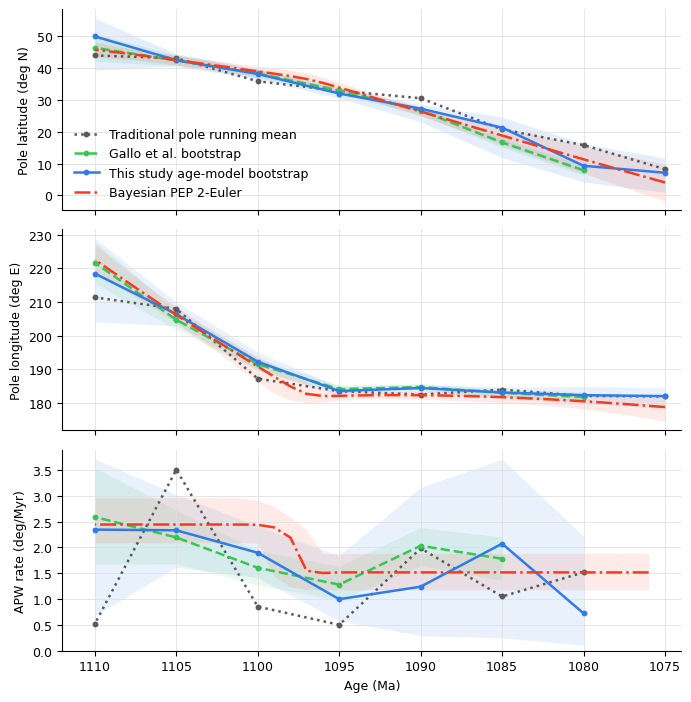

In [6]:
traditional = traditional_rm[traditional_rm.age.isin(FIVE_MYR_EFFECTIVE_AGES)].copy()
traditional = traditional.drop(columns=['APW_rate'], errors='ignore').assign(run=0)
traditional = calculate_coherent_path_rates(traditional)
traditional_path = traditional[['age', 'plon', 'plat']].copy()
traditional_path['plon_q50'] = traditional_path.plon
traditional_path['plat_q50'] = traditional_path.plat
traditional_rate = traditional[['age', 'APW_rate']].rename(columns={'APW_rate': 'q50'})

updated_path = cartesian_mean_path(
    updated_rm[updated_rm.effective_age.isin(FIVE_MYR_EFFECTIVE_AGES)], age_col='effective_age'
)
baseline_path = cartesian_mean_path(
    gallo_rm[gallo_rm.effective_age.isin(baseline_5myr_effective_ages)], age_col='effective_age'
)
pep_path = cartesian_mean_path(pep_paths)
pep_rate = summarize_quantiles(pep_paths)

summaries = {
    'Traditional pole running mean': (traditional_path, traditional_rate),
    'Gallo et al. bootstrap': (baseline_path, baseline_rate_5myr),
    'This study age-model bootstrap': (updated_path, updated_rate_5myr),
    'Bayesian PEP 2-Euler': (pep_path, pep_rate),
}
colors = {
    'Traditional pole running mean': '#595959', 'Gallo et al. bootstrap': '#36C753',
    'This study age-model bootstrap': '#2F7CE8', 'Bayesian PEP 2-Euler': '#F73A1D',
}
linestyles = {
    'Traditional pole running mean': ':', 'Gallo et al. bootstrap': '--',
    'This study age-model bootstrap': '-', 'Bayesian PEP 2-Euler': '-.',
}

for method, (path_summary, rate_summary) in summaries.items():
    safe = method.lower().replace(' ', '_').replace('-', '_').replace('.', '')
    path_summary.to_csv(OUTPUT_DIR / f'revision_method_comparison_{safe}_path.csv', index=False)
    rate_summary.to_csv(OUTPUT_DIR / f'revision_method_comparison_{safe}_rate.csv', index=False)

fig, axes = plt.subplots(3, 1, figsize=(7.0, 7.1), sharex=True)
for method, (path_summary, rate_summary) in summaries.items():
    color, ls = colors[method], linestyles[method]
    marker = None if method == 'Bayesian PEP 2-Euler' else 'o'
    axes[0].plot(path_summary.age, path_summary.plat_q50, color=color, ls=ls, lw=1.8, marker=marker, ms=3.2, label=method)
    axes[1].plot(path_summary.age, path_summary.plon_q50, color=color, ls=ls, lw=1.8, marker=marker, ms=3.2)
    axes[2].plot(rate_summary.age, rate_summary.q50, color=color, ls=ls, lw=1.8, marker=marker, ms=3.2)
    if 'plat_q025' in path_summary and method != 'Traditional pole running mean':
        axes[0].fill_between(path_summary.age, path_summary.plat_q025, path_summary.plat_q975, color=color, alpha=0.12, lw=0)
        axes[1].fill_between(path_summary.age, path_summary.plon_q025, path_summary.plon_q975, color=color, alpha=0.10, lw=0)
    if 'q025' in rate_summary and method != 'Traditional pole running mean':
        axes[2].fill_between(rate_summary.age, rate_summary.q025, rate_summary.q975, color=color, alpha=0.10, lw=0)
axes[0].set_ylabel('Pole latitude (deg N)')
axes[1].set_ylabel('Pole longitude (deg E)')
axes[2].set_ylabel('APW rate (deg/Myr)')
axes[2].set_xlabel('Age (Ma)')
axes[2].set_ylim(bottom=0)
axes[2].set_xlim(1112, 1074)
for ax in axes:
    ax.grid(True, color='0.88', lw=0.6)
axes[0].legend(frameon=False, loc='lower left')
fig.tight_layout()
# for destination in [LOCAL_FIGURE_DIR, MANUSCRIPT_FIGURE_DIR]:
#     fig.savefig(destination / 'SI_APWP_method_comparison.pdf', bbox_inches='tight')
plt.show()

## Figure S8: effect of 1 Myr versus 5 Myr spacing

Both curves use the same 15 Myr moving-window ensemble and the same Gallo pooled effective-age resampling. Their only intended difference is the spacing between sampled effective ages. A 1 Myr segment is more sensitive to local pole scatter, whereas a 5 Myr great-circle chord averages displacement across a longer interval; consequently the curves should show the same broad evolution but need not coincide point by point.

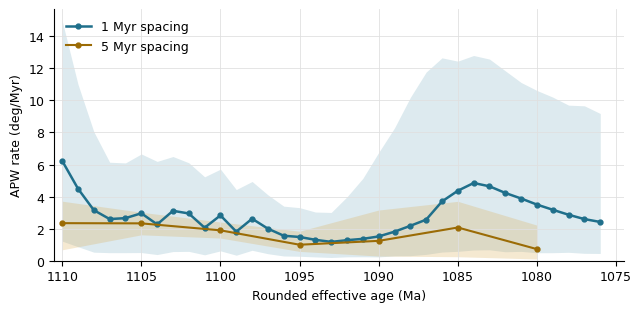

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.fill_between(updated_rate_1myr.age, updated_rate_1myr.q025, updated_rate_1myr.q975, color='#86B6C6', alpha=0.28, lw=0)
ax.plot(updated_rate_1myr.age, updated_rate_1myr.q50, color='#1F6F8B', lw=1.8, marker='o', ms=3.5, label='1 Myr spacing')
ax.fill_between(updated_rate_5myr.age, updated_rate_5myr.q025, updated_rate_5myr.q975, color='#D9A441', alpha=0.24, lw=0)
ax.plot(updated_rate_5myr.age, updated_rate_5myr.q50, color='#9B6B05', lw=1.5, marker='o', ms=3.5, label='5 Myr spacing')
ax.set_xlim(1110.5, 1074.5)
ax.set_ylim(bottom=0)
ax.set_xlabel('Rounded effective age (Ma)')
ax.set_ylabel('APW rate (deg/Myr)')
ax.grid(True, color='0.88', lw=0.6)
ax.legend(frameon=False, loc='upper left')
fig.tight_layout()
for destination in [LOCAL_FIGURE_DIR, MANUSCRIPT_FIGURE_DIR]:
    fig.savefig(destination / 'SI_APW_rate_1Myr_comparison.pdf', bbox_inches='tight')
# fig.savefig(DOWNLOAD_DIR / 'Figure_S8_Gallo_pooled_effective_age.pdf', bbox_inches='tight')
plt.show()

## Coauthor comparison: trajectory-coherent rate sampling

For discussion among coauthors, this cell reconstructs the lower-uncertainty alternative considered previously. It calculates rates between adjacent poles from the same bootstrap realization and indexes them by the prescribed moving-window center age. The 5 Myr result similarly connects 5 Myr-spaced poles within each original run. This preserves temporal covariance but differs from the pooled rounded-effective-age estimator used by Gallo et al. (2023) and Figures 5 and S8. The alternative is exported only to the Downloads folder and does not replace the manuscript figure.

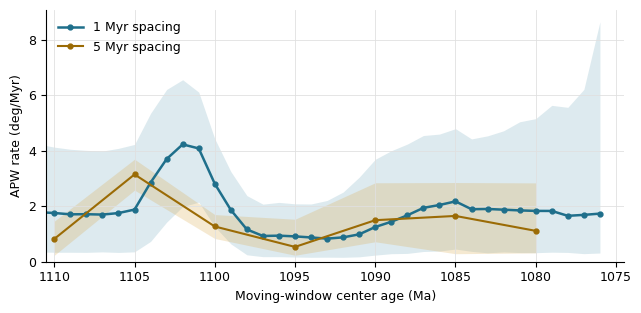

In [8]:
coherent_rate_1myr = summarize_quantiles(updated_rm, 'age', 'APW_rate')
coherent_5myr_paths = updated_rm[updated_rm.age.isin(FIVE_MYR_EFFECTIVE_AGES)].copy()
coherent_5myr_paths = coherent_5myr_paths.drop(columns=['APW_rate'], errors='ignore')
coherent_5myr_paths = calculate_coherent_path_rates(coherent_5myr_paths)
coherent_rate_5myr = summarize_quantiles(coherent_5myr_paths, 'age', 'APW_rate')

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.fill_between(coherent_rate_1myr.age, coherent_rate_1myr.q025, coherent_rate_1myr.q975, color='#86B6C6', alpha=0.28, lw=0)
ax.plot(coherent_rate_1myr.age, coherent_rate_1myr.q50, color='#1F6F8B', lw=1.8, marker='o', ms=3.5, label='1 Myr spacing')
ax.fill_between(coherent_rate_5myr.age, coherent_rate_5myr.q025, coherent_rate_5myr.q975, color='#D9A441', alpha=0.24, lw=0)
ax.plot(coherent_rate_5myr.age, coherent_rate_5myr.q50, color='#9B6B05', lw=1.5, marker='o', ms=3.5, label='5 Myr spacing')
ax.set_xlim(1110.5, 1074.5)
ax.set_ylim(bottom=0)
ax.set_xlabel('Moving-window center age (Ma)')
ax.set_ylabel('APW rate (deg/Myr)')
ax.grid(True, color='0.88', lw=0.6)
ax.legend(frameon=False, loc='upper left')
fig.tight_layout()
# fig.savefig(DOWNLOAD_DIR / 'Figure_S8_trajectory_coherent_window_center_age.pdf', bbox_inches='tight')
plt.show()

## Interpretation and retained sensitivity test

The figures above intentionally reproduce the published Gallo effective-age estimator. This makes their rates comparable with Figure 5, but the independent pooling step discards covariance between neighboring poles in an original bootstrap realization. For a future methodological comparison, `calculate_coherent_path_rates` can instead connect adjacent poles carrying the same `run` identifier. That alternative answers a different statistical question and should be labeled explicitly rather than mixed into the published convention.